# Exploratory Data Analysis – Xente Transaction Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/raw/data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [4]:
df = pd.read_csv('../data/raw/Xente_Variable_Definitions.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (16, 2)


,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account


In [5]:
df.info()
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Column Name  16 non-null     str  
 1   Definition   16 non-null     str  
dtypes: str(2)
memory usage: 388.0 bytes
Duplicate rows: 0


In [6]:
df.describe(include='all')

,Column Name,Definition
count,16,16
unique,16,16
top,TransactionId,Unique �transaction identifier on platform
freq,1,1


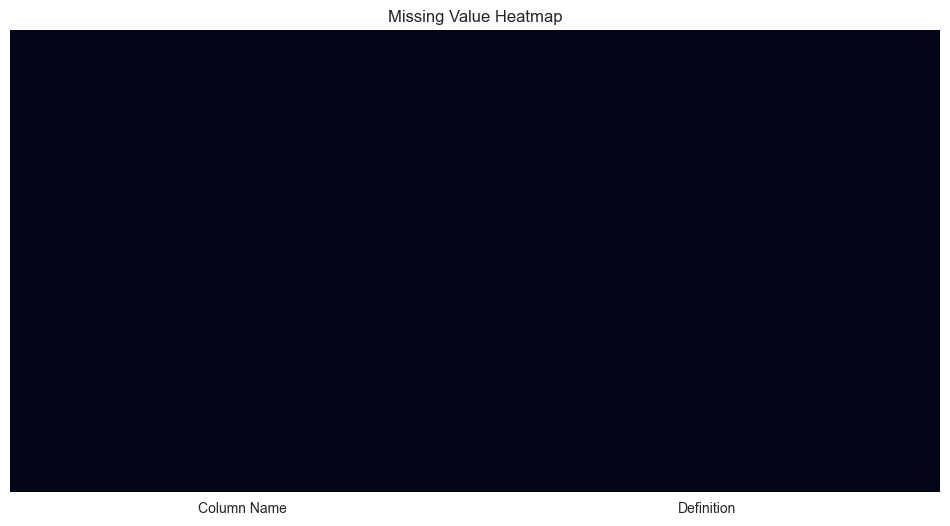

In [7]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap')
plt.show()

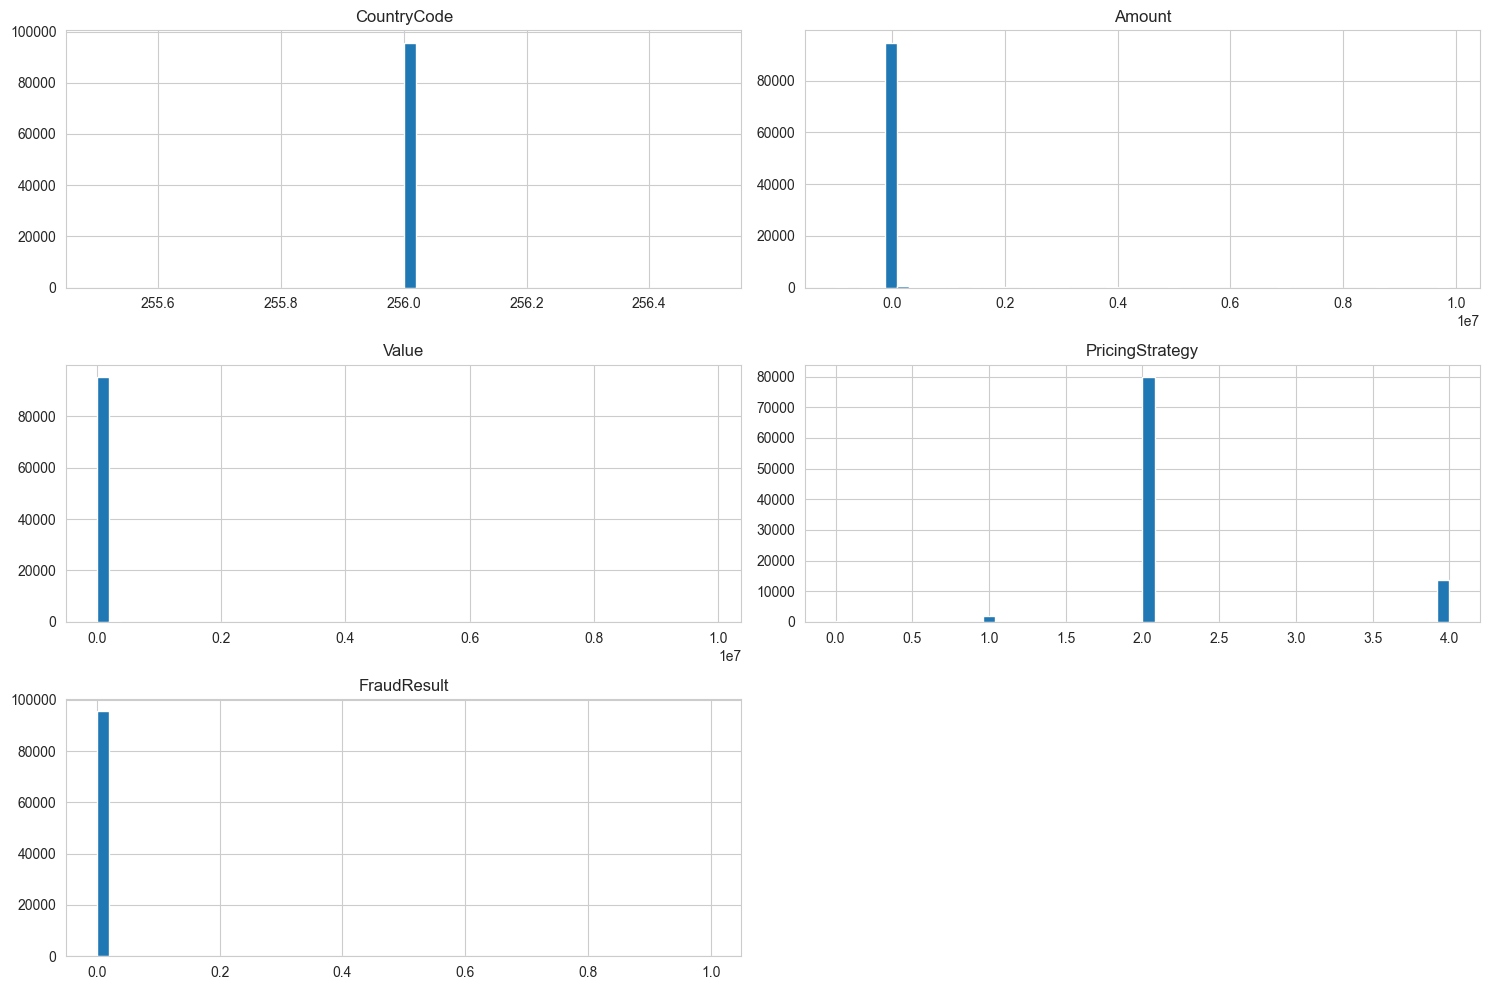

In [20]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(figsize=(15,10), bins=50)
plt.tight_layout()
plt.show()

C:\Users\kidim\AppData\Local\Temp\ipykernel_23748\3212895022.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns
C:\Users\kidim\AppData\Local\Temp\ipykernel_23748\3212895022.py:6: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\kidim\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


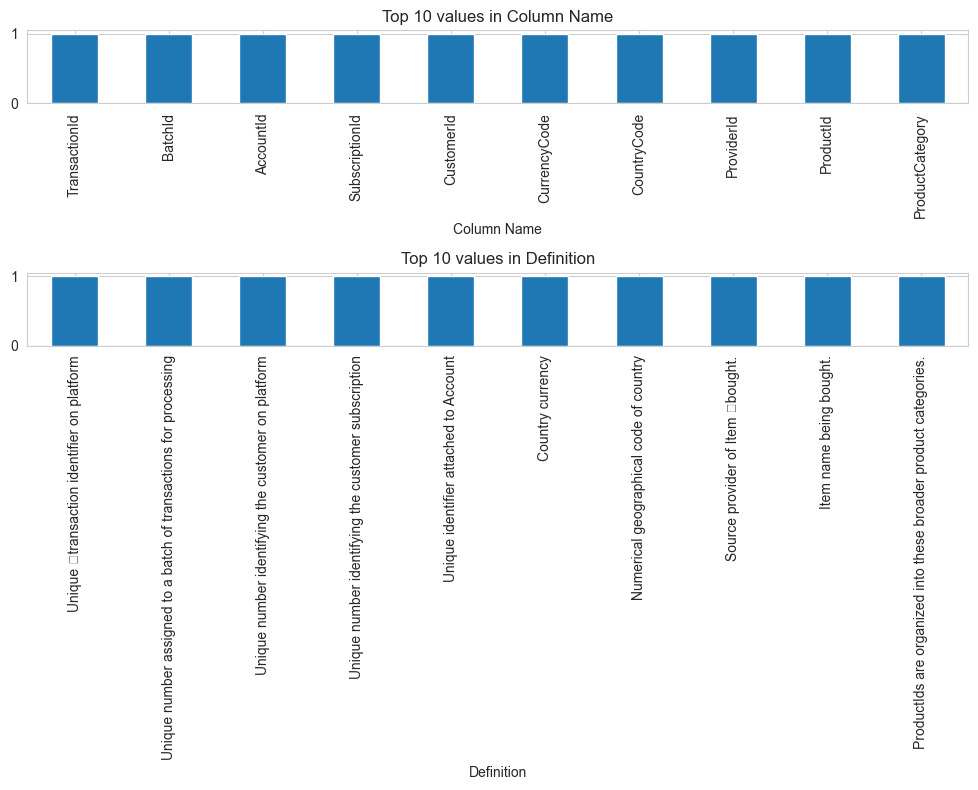

In [9]:
cat_cols = df.select_dtypes(include='object').columns
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4*len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(f'Top 10 values in {col}')
plt.tight_layout()
plt.show()

In [ ]:
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
df['hour'] = df['TransactionStartTime'].dt.hour
df['day'] = df['TransactionStartTime'].dt.day
df['month'] = df['TransactionStartTime'].dt.month
df['year'] = df['TransactionStartTime'].dt.year

df.set_index('TransactionStartTime').resample('D')['TransactionId'].count().plot(figsize=(12,4))
plt.title('Daily Transaction Count')
plt.show()

KeyError: 'TransactionStartTime'

In [12]:
print(df.columns)

Index(['Column Name', 'Definition'], dtype='str')


In [14]:
corr_cols = ['TransactionId','BatchId','AccountId','SubscriptionId','CustomerId','CurrencyCode','CountryCode','ProviderId','ProductId','ProductCategory','ChannelId','Amount','Value','TransactionStartTime','PricingStrategy','FraudResult']
corr = df[corr_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

KeyError: "None of [Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',\n       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',\n       'ProductCategory', 'ChannelId', 'Amount', 'Value',\n       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],\n      dtype='str')] are in the [columns]"

In [18]:
df=pd.read_csv('../data/raw/data.csv')
print(df.columns)

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')


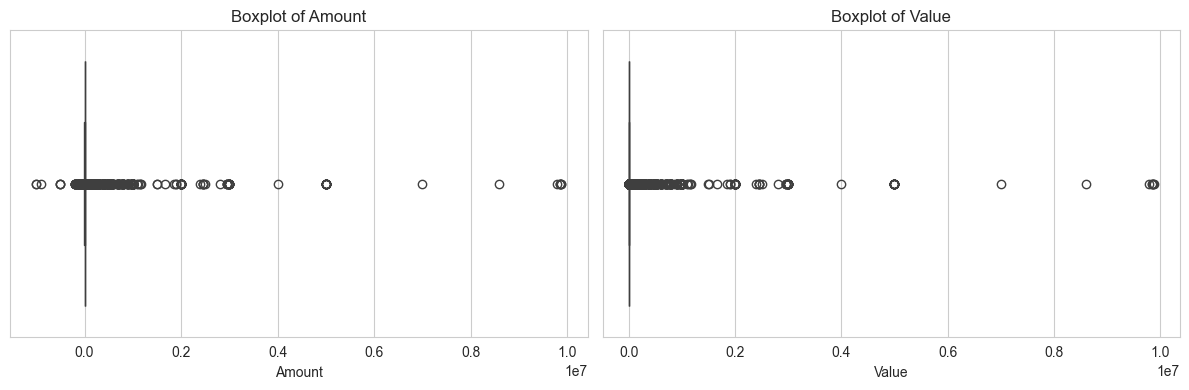

In [19]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(x=df['Amount'], ax=axes[0])
axes[0].set_title('Boxplot of Amount')
sns.boxplot(x=df['Value'], ax=axes[1])
axes[1].set_title('Boxplot of Value')
plt.tight_layout()
plt.show()

### Top 3–5 Insights from EDA

1. **Skewed transaction amounts**: `Amount` and `Value` are highly right‑skewed; most transactions are small, but extreme values exist, requiring log‑transformation or capping.
2. **Low fraud incidence**: `FraudResult` is severely imbalanced (~0.2% fraud). It can't serve as the primary default proxy, but it may be a weak risk signal.
3. **Minimal missing data**: Less than 1% of rows have missing values, mostly in `ProductCategory` and `ChannelId`. Simple mode imputation will suffice.
4. **Temporal patterns**: Transaction volumes show clear weekly and monthly seasonality. Derived features (`hour`, `day`, `month`) are useful for engagement modelling.
5. **Categorical concentration**: `ProductCategory` "airtime" and `ChannelId` "web" dominate. WoE binning will effectively handle the high cardinality.